In [1]:
"""
Unit 5: Evolving Your IPD Agent with Genetic Algorithms
========================================================

In Unit 4, you hand-coded agent strategies like Tit-for-Tat.
In Unit 5, you'll use evolution to DISCOVER strategies automatically.

By the end, you'll have an evolved agent saved as a JSON file for the tournament!
"""

# ============================================================================
# SETUP: Import everything from previous units
# ============================================================================

import random
import numpy as np
import json
import matplotlib.pyplot as plt
from agents import Agent, INVEST, UNDERCUT
from game_engine import Game, Tournament

# Import all hand-coded agents from Unit 4
from agents import (
    AlwaysInvestAgent, AlwaysUndercutAgent, TitForTatAgent,
    GrimTriggerAgent, PavlovAgent, TitForTwoTatsAgent,
    GenerousTitForTatAgent, AdaptiveAgent, RandomAgent,
    SuspiciousTitForTatAgent, GradualAgent, HardMajorityAgent,
    SoftMajorityAgent, ProberAgent
)

print("✅ Imports complete!")

✅ Imports complete!


In [3]:

# ============================================================================
# PART 1: THE EVOLVABLE AGENT (PROVIDED - Read but don't modify)
# ============================================================================

class EvolvableAgent(Agent):
    """
    An agent whose strategy is controlled by 6 genes (numbers from 0 to 1).
    
    Think of genes as "strategy dials" you can tune:
    
    Gene[0] - Initial Cooperation (0=hostile start, 1=friendly start)
    Gene[1] - Cooperation Response (if opponent cooperates, how likely to cooperate back?)
    Gene[2] - Defection Response (if opponent defects, how likely to defect back?)
    Gene[3] - Forgiveness (after retaliation, chance to forgive)
    Gene[4] - Memory Length (0=last 1 round, 1=last 10 rounds)
    Gene[5] - Retaliation Threshold (what % of defections triggers retaliation)
    """
    
    def __init__(self, genes=None, name="Evolved Agent"):
        if genes is None:
            # Create random genes if none provided
            genes = [random.random() for _ in range(6)]
        
        self.genes = genes
        super().__init__(name, f"Genes: [{', '.join([f'{g:.2f}' for g in genes])}]")
    
    def choose_action(self) -> bool:
        """Decision logic based on genes - SIMPLIFIED FOR LEARNING"""
        
        # First 3 rounds: use initial cooperation gene
        if self.round_num < 3:
            return random.random() < self.genes[0]
        
        # Calculate memory window (gene[4])
        memory_length = max(1, int(self.genes[4] * 10) + 1)
        recent_history = self.history[-memory_length:]
        
        # Calculate opponent's recent COOPERATION rate (not defection!)
        cooperation_rate = sum(recent_history) / len(recent_history)
        
        # If opponent is mostly cooperating, reciprocate
        if cooperation_rate >= 0.5:
            return random.random() < self.genes[1]  # gene[1] = cooperate response
        
        # If opponent is mostly defecting, retaliate or forgive
        else:
            # Retaliate with probability gene[2]
            if random.random() < self.genes[2]:
                return UNDERCUT
            # Or forgive with probability gene[3]
            elif random.random() < self.genes[3]:
                return INVEST
            else:
                return UNDERCUT


In [4]:

# ============================================================================
# PART 2: DEFINE THE OPPONENT ECOSYSTEM
# ============================================================================

# ============================================================================
# EXPANDED OPPONENT POOL
# ============================================================================

# Full pool of all possible opponents
full_opponent_pool = [
    # Cooperative agents
    AlwaysInvestAgent(),
    TitForTatAgent(),
    GrimTriggerAgent(),
    PavlovAgent(),
    TitForTwoTatsAgent(),
    GenerousTitForTatAgent(),
    AdaptiveAgent(),
    
    # Aggressive agents
    AlwaysUndercutAgent(),
    SuspiciousTitForTatAgent(),
    
    # Sophisticated agents
    GradualAgent(),
    ProberAgent(),
    
    # Majority-based agents
    HardMajorityAgent(),
    SoftMajorityAgent(),
    
    # Random agents with different cooperation levels
    RandomAgent(0.9),
    RandomAgent(0.7),
    RandomAgent(0.5),
    RandomAgent(0.3),
    RandomAgent(0.1),
]

print(f"\n📚 Full opponent library: {len(full_opponent_pool)} agents available")

# For initial evolution, randomly sample opponents
opponent_pool = random.sample(full_opponent_pool, 10)

print(f"🎲 Randomly selected {len(opponent_pool)} opponents for this evolution:")
for i, opp in enumerate(opponent_pool, 1):
    print(f"  {i:2d}. {opp.name:25s} - {opp.description}")
print("="*70)




📚 Full opponent library: 18 agents available
🎲 Randomly selected 10 opponents for this evolution:
   1. Generous Tit-for-Tat      - Tit-for-Tat with 10% forgiveness
   2. Adaptive                  - Adapts to opponent's cooperation rate
   3. Tit-for-Two-Tats          - Tolerates one betrayal, retaliates after two
   4. Grim Trigger              - Invests until betrayed once, then undercuts forever
   5. Suspicious Tit-for-Tat    - Starts hostile, then copies opponent
   6. Random (0.3)              - Randomly invests 30% of the time
   7. Random (0.7)              - Randomly invests 70% of the time
   8. Random (0.1)              - Randomly invests 10% of the time
   9. Random (0.5)              - Randomly invests 50% of the time
  10. Hard Majority             - Defects if opponent defects >50% of time


In [5]:

# ============================================================================
# PART 3: GENETIC ALGORITHM FUNCTIONS (YOUR TODO!)
# ============================================================================

def initialize_population(pop_size):
    """
    Create initial population of random agents.
    
    Args:
        pop_size: Number of agents in population
    
    Returns:
        List of EvolvableAgent objects with random genes
    """
    population = []
    for i in range(pop_size):
        agent = EvolvableAgent(name=f"Agent_{i}")
        population.append(agent)
    return population


def evaluate_fitness(agent, opponents, num_rounds=50):
    """
    Measure how good an agent is by playing against all opponents.
    
    Args:
        agent: The EvolvableAgent to evaluate
        opponents: List of opponent agents to play against
        num_rounds: Number of rounds per game
    
    Returns:
        Float: Average score per game (higher is better)
    """
    total_score = 0
    num_games = 0
    
    for opponent in opponents:
        game = Game(agent, opponent, num_rounds=num_rounds)
        score, _ = game.play()
        total_score += score
        num_games += 1
    
    avg_score = total_score / num_games
    return avg_score


def tournament_selection(population, fitnesses, tournament_size=3):
    """
    Select parents using tournament selection.
    
    Tournament selection:
    1. Pick tournament_size random individuals
    2. Choose the one with best fitness
    3. Repeat until we have pop_size selected parents
    
    Args:
        population: List of agents
        fitnesses: List of fitness scores (parallel to population)
        tournament_size: How many agents compete in each tournament
    
    Returns:
        List of selected agents (same length as population)
    """
    selected = []
    
    for _ in range(len(population)):
        # Pick random contestants
        contestants_idx = random.sample(range(len(population)), tournament_size)
        
        # Find the one with best fitness
        best_idx = max(contestants_idx, key=lambda i: fitnesses[i])
        
        # Add winner to selected (make a copy of genes)
        winner_genes = population[best_idx].genes.copy()
        selected.append(EvolvableAgent(genes=winner_genes))
    
    return selected


def crossover_and_mutate(parent1, parent2, mutation_rate=0.15):
    """
    Create a child from two parents using crossover and mutation.
    
    Crossover (single-point):
    1. Pick a random split point (1 to 5)
    2. Take genes before split from parent1
    3. Take genes after split from parent2
    
    Mutation:
    1. For each gene, with probability=mutation_rate:
    2. Add Gaussian noise (mean=0, std=0.2)
    3. Clip gene to stay in range [0, 1]
    
    Args:
        parent1: First parent EvolvableAgent
        parent2: Second parent EvolvableAgent
        mutation_rate: Probability of mutating each gene
    
    Returns:
        New EvolvableAgent (the child)
    """
    # Crossover
    crossover_point = random.randint(1, 5)  # Random split between 1 and 5
    child_genes = (parent1.genes[:crossover_point] + 
                   parent2.genes[crossover_point:])
    
    # Mutation
    for i in range(len(child_genes)):
        if random.random() < mutation_rate:
            # Add random noise
            child_genes[i] += random.gauss(0, 0.2)
            # Keep gene in valid range [0, 1]
            child_genes[i] = max(0.0, min(1.0, child_genes[i]))
    
    return EvolvableAgent(genes=child_genes)


def evolve(generations=25, pop_size=20, opponents=None, mutation_rate=0.15, elitism=2):
    """
    Run the genetic algorithm to evolve an agent.
    
    Process:
    1. Create initial random population
    2. For each generation:
       a. Evaluate fitness of all agents
       b. Select parents via tournament selection
       c. Create children via crossover & mutation
       d. Keep best agents (elitism)
    3. Return the best agent found
    
    Args:
        generations: Number of generations to evolve
        pop_size: Size of population
        opponents: List of opponents to evaluate against
        mutation_rate: Probability of gene mutation
        elitism: Number of best agents to keep unchanged
    
    Returns:
        Best EvolvableAgent found
    """
    if opponents is None:
        opponents = opponent_pool
    
    print(f"\n🧬 EVOLUTION STARTING")
    print(f"{'='*70}")
    print(f"Population: {pop_size} | Generations: {generations} | Mutation: {mutation_rate}")
    print(f"Opponents: {len(opponents)} | Elitism: {elitism}")
    print(f"{'='*70}\n")
    
    # Track statistics
    best_fitness_history = []
    avg_fitness_history = []
    
    # Initialize population
    population = initialize_population(pop_size)
    
    best_overall_agent = None
    best_overall_fitness = -float('inf')
    
    # Evolution loop
    for gen in range(generations):
        # Evaluate fitness for all agents
        fitnesses = []
        for agent in population:
            fitness = evaluate_fitness(agent, opponents, num_rounds=50)
            fitnesses.append(fitness)
        
        # Track best and average
        best_fitness = max(fitnesses)
        avg_fitness = sum(fitnesses) / len(fitnesses)
        best_idx = fitnesses.index(best_fitness)

        # Sanity check: best fitness should never decrease (elitism guarantee)
        if gen > 0 and best_fitness < best_fitness_history[gen-1]:
            print(f"⚠️  WARNING: Best fitness decreased from {best_fitness_history[gen-1]:.2f} to {best_fitness:.2f}")
            print(f"    This suggests a bug in elitism or fitness evaluation!")
        
        # Track best agent ever seen
        if best_fitness > best_overall_fitness:
            best_overall_fitness = best_fitness
            # CRITICAL: Make a deep copy so genes don't get mutated later
            best_overall_agent = EvolvableAgent(genes=population[best_idx].genes.copy())
            print("Best Genes:", best_overall_agent.genes)

        # Update the history status after, so it doesn't lag behind
        best_fitness_history.append(best_overall_fitness)
        avg_fitness_history.append(avg_fitness)
        
        # Print progress
        print(f"Gen {gen+1:3d}/{generations}: "
              f"Best={best_fitness:6.2f} | Avg={avg_fitness:6.2f} | "
              f"Genes={[f'{g:.2f}' for g in population[best_idx].genes]}")
        
        # Create next generation (unless this is the last generation)
        if gen < generations - 1:
            # Sort population by fitness for elitism
            sorted_indices = sorted(range(len(fitnesses)), 
                                  key=lambda i: fitnesses[i], 
                                  reverse=True)
            
            # Keep elite agents (top performers)
            next_population = []
            for i in range(elitism):
                elite_genes = population[sorted_indices[i]].genes.copy()
                next_population.append(EvolvableAgent(genes=elite_genes))
            
            # Selection
            selected = tournament_selection(population, fitnesses)
            
            # Create offspring to fill rest of population
            while len(next_population) < pop_size:
                parent1, parent2 = random.sample(selected, 2)
                child = crossover_and_mutate(parent1, parent2, mutation_rate)
                next_population.append(child)
            
            population = next_population
    
    print(f"\n{'='*70}")
    print(f"✅ EVOLUTION COMPLETE!")
    print(f"🏆 Best fitness achieved: {best_overall_fitness:.2f}")
    print(f"{'='*70}\n")
    
    # Plot evolution progress
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, generations+1), best_fitness_history, 
             label='Best Fitness', linewidth=2, color='green', marker='o')
    plt.plot(range(1, generations+1), avg_fitness_history, 
             label='Average Fitness', linewidth=2, color='blue', marker='s', alpha=0.7)
    plt.xlabel('Generation', fontsize=12)
    plt.ylabel('Fitness (Avg Score per Game)', fontsize=12)
    plt.title('Evolution Progress', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return best_overall_agent




🚀 TIME TO EVOLVE YOUR AGENT!

🧬 EVOLUTION STARTING
Population: 30 | Generations: 100 | Mutation: 0.1
Opponents: 10 | Elitism: 2

Best Genes: [0.7217330810582391, 0.9345511322353275, 0.9305653324133896, 0.7761853780374977, 0.9573238899507629, 0.4327610265213423]
Gen   1/100: Best=127.10 | Avg= 99.47 | Genes=['0.72', '0.93', '0.93', '0.78', '0.96', '0.43']
⚠️  WARNING: Best fitness decreased from 127.10 to 117.80
    This suggests a bug in elitism or fitness evaluation!
Gen   2/100: Best=117.80 | Avg=104.51 | Genes=['0.64', '0.94', '0.39', '0.36', '0.63', '0.80']
Gen   3/100: Best=127.10 | Avg=110.01 | Genes=['0.90', '1.00', '0.50', '0.10', '0.58', '0.10']
Best Genes: [0.882271043904513, 1.0, 0.49978202735214494, 0.09730430713222255, 0.5208198473669241, 0.09782573693946561]
Gen   4/100: Best=128.90 | Avg=110.93 | Genes=['0.88', '1.00', '0.50', '0.10', '0.52', '0.10']
Best Genes: [0.882271043904513, 1.0, 0.49978202735214494, 0.09730430713222255, 0.5208198473669241, 0.09782573693946561]
G

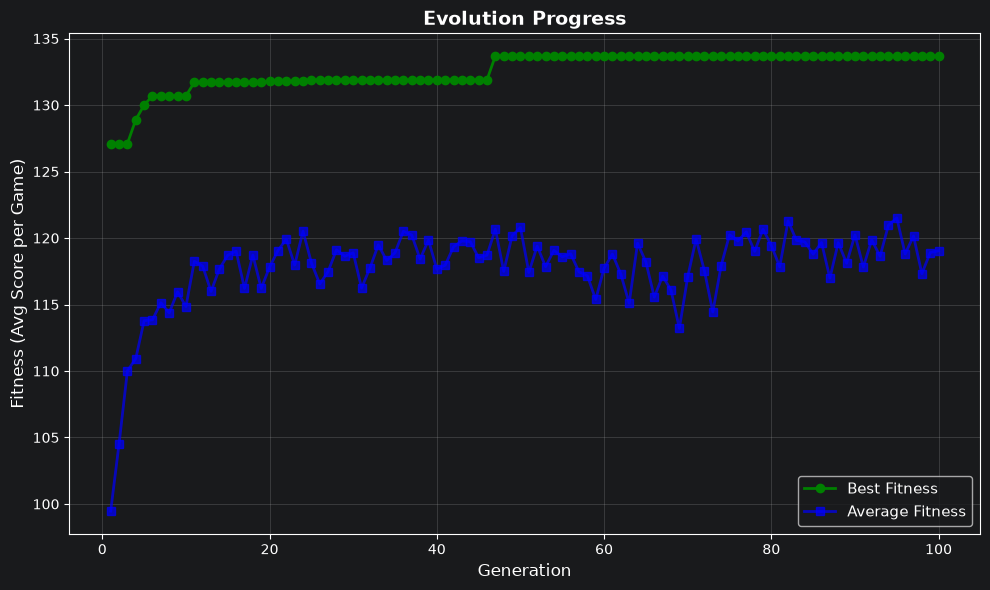


🎉 Your evolved agent's final genes:
   [0.6884797331279742, 1.0, 1.0, 0.0, 0.24427311801590001, 0.12206781058468015]


In [17]:

# ============================================================================
# PART 4: RUN EVOLUTION! 
# ============================================================================

print("\n" + "="*70)
print("🚀 TIME TO EVOLVE YOUR AGENT!")
print("="*70)

# Original Settings
my_evolved_agent = evolve(
    generations=100,       # Try: 50, 100, 250
    pop_size=30,         # Try: 15, 20, 30
    opponents=opponent_pool,
    mutation_rate=0.1,  # Try: 0.1, 0.15, 0.2
    elitism=2            # Keep top 2 agents each generation
)

# Test Settings 1
# my_evolved_agent = evolve(
#     generations=10000,       # Try: 50, 100, 250
#     pop_size=100,         # Try: 15, 20, 30
#     opponents=opponent_pool,
#     mutation_rate=0.4,  # Try: 0.1, 0.15, 0.2
#     elitism=2            # Keep top 2 agents each generation
# )

# Test Settings 2
# my_evolved_agent = evolve(
#     generations=1000,       # Try: 50, 100, 250
#     pop_size=1000,         # Try: 15, 20, 30
#     opponents=opponent_pool,
#     mutation_rate=0.2,  # Try: 0.1, 0.15, 0.2
#     elitism=100            # Keep top 2 agents each generation
# )
# Output: [0.9353212785426339, 0.588499459816107, 1.0, 1.0, 1.0, 0.7606197205157933]

# Overnight Settings
# my_evolved_agent = evolve(
#     generations=100000,       # Try: 50, 100, 250
#     pop_size=1000,         # Try: 15, 20, 30
#     opponents=opponent_pool,
#     mutation_rate=0.8,  # Try: 0.1, 0.15, 0.2
#     elitism=10            # Keep top 2 agents each generation
# )
# Output: [0.70934339537907, 0.6001439278148997, 1.0, 0.0665389322265733, 1.0, 0.8415669044504163]

print(f"\n🎉 Your evolved agent's final genes:")
print(f"   {my_evolved_agent.genes}")



In [19]:

# ============================================================================
# PART 5: TEST YOUR AGENT
# ============================================================================

print("\n" + "="*70)
print("⚔️  TESTING YOUR AGENT AGAINST HAND-CODED OPPONENTS")
print("="*70 + "\n")

wins = 0
losses = 0
ties = 0

for opponent in opponent_pool:
    game = Game(my_evolved_agent, opponent, num_rounds=100)
    my_score, opp_score = game.play()
    
    if my_score > opp_score:
        result = "✅ WON"
        wins += 1
    elif my_score < opp_score:
        result = "❌ LOST"
        losses += 1
    else:
        result = "🤝 TIED"
        ties += 1
    
    print(f"vs {opponent.name:25s}: {my_score:3d} - {opp_score:3d}  {result}")

print(f"\n📊 Record: {wins} wins, {losses} losses, {ties} ties")
win_rate = wins / len(opponent_pool) * 100
print(f"🎯 Win Rate: {win_rate:.1f}%")




⚔️  TESTING YOUR AGENT AGAINST HAND-CODED OPPONENTS

vs Always Undercut          :  98 - 108  ❌ LOST
vs Adaptive                 : 295 - 290  ✅ WON
vs Prober                   : 101 - 116  ❌ LOST
vs Random (0.7)             : 241 - 296  ❌ LOST
vs Grim Trigger             : 102 - 107  ❌ LOST
vs Tit-for-Tat              : 300 - 300  🤝 TIED
vs Random (0.3)             : 181 - 156  ✅ WON
vs Tit-for-Two-Tats         : 300 - 300  🤝 TIED
vs Generous Tit-for-Tat     : 301 - 296  ✅ WON
vs Suspicious Tit-for-Tat   : 103 - 103  🤝 TIED

📊 Record: 3 wins, 4 losses, 3 ties
🎯 Win Rate: 30.0%


# Unit 5 Part 2: Benchmark Analysis

**After running your initial evolution and benchmark tests, answer these questions.**

---

## Performance Summary

Fill in your benchmark results:

| Opponent         |   Result (W/L/T)    | Your Score | Opp Score |
|------------------|:-------------------:|-----------:|----------:|
| Soft Majority    |          W          |        364 |       204 |
| Hard Majority    |          W          |        372 |       192 |
| Gradual          |          W          |        187 |       117 |
| Prober           |          L          |        101 |       116 |
| Always Invest    |          W          |        372 |       192 |
| Tit-for-Two-Tats |          W          |        326 |       216 |
| Random (0.3)     |          W          |        232 |       117 |
| Pavlov           |          W          |        267 |       112 |
| Random (0.5)     |          W          |        246 |       161 |
| Random (0.1)     |          W          |        157 |        97 |
| **Total**        | **9 W / 1 L / 0 T** |  **2,624** | **1,524** |


---

## Analysis Questions

### 1. What was your agent's worst loss (greatest point differential) and why?

My agent's worst loss was against Prober by around 15 points. Prober was designed to test betraying to see if it can exploit my agent and it has succeeded most of the time. This is because my agent is not really aware that it is being tested, it is only aware that the other bots will maintain a consistent behavior either random or on a condition.

---

### 2. What pattern do you see in wins vs. losses?

(Which types of opponents does your agent beat/lose to? What do those agent types have in common?)

I cannot really say much in regards to the losses, since it only keeps losing to Prober. But in regards to winning, it beats a constant behavior or rule based and even random ones. Basically beats anything as long as it doesn't get exploited or abused like against Prober.

---

### 3. What would make an agent more competitive?

I tried making the agent more competitive by having a longer training period, around 18 hours to be exact, but the improvements were small. More training and more practice does not help much. To make it more competitive, I would rather it figure out the type of agent too, like Prober. But the agent would be a hybrid, this would be running a similar ruleset to my unit 4, but with the strength of processing through evolution to know when it is abused. It should also maximize points when it knows it is being exploited. That smaller difference would help it consistently beat Prober and most of the other bots.

---

**Next:** Proceed to Part 3 to implement your improvements!

In [153]:
import random
import json


# ============================================================================
# PART 6: IMPROVE YOUR AGENT'S ACTION TAKING STRATEGY
# ============================================================================

class ImprovedEvolvableAgent(Agent):
    """
    IMPROVED agent with better gene encoding

    Students can modify:
    - Number of genes
    - What genes control
    - Decision logic
    """

    def __init__(self, genes=None, name="KiasuBOT"):
        if genes is None:
            # Can change number of genes here
            genes = [random.random() for _ in range(6)]

        self.genes = genes
        self.retaliate = False

        super().__init__(
            name,
            f"Genes: [{', '.join([f'{g:.2f}' for g in genes])}]"
        )

    def choose_action(self) -> bool:
        """
        Fuzzy Logic Time!!! Modified from Unit 04 to Fit Here

        Genes:
        [0] initial cooperation
        [1] initial strategy duration
        [2] cooperate with cooperative opponents
        [3] forgiveness
        [4] memory length
        [5] consecutive defection tolerance
        """

        # Set Genes for Easier Read
        initial_cooperation = self.genes[0]
        initial_strategy_duration = self.genes[1]
        cooperation_prob = self.genes[2] # KEEPS MAXING OUT, DO WE NEED TO CHANGE?
        forgiveness = self.genes[3]
        memory = self.genes[4]
        defection_tolerance = self.genes[5]

        # TODO: Testing Prevention against Prober
        # FROM UNIT 04: WE NEEDED A CLASSIFIER FOR MODEL, SO CHECK FOR BEHAVIOR

        # NICE FOR ROUND 1
        if self.round_num == 0:
            return INVEST

        # Stuff from Unit 04
        last = self.history[-1]

        # PUNISH IF STARTED WITH UNDERCUT
        if self.round_num == 1:
            if last == UNDERCUT:
                return UNDERCUT

            else:
                return INVEST

        # MAKE SURE WE HAVE ENOUGH HISTORY
        last_last = self.history[-2]
        first_two = self.history[:2]

        # EVALUATE THE OPPONENT AND THEIR TYPES
        if self.round_num == 2:
            # IF THEY UNDERCUT TWICE, START RETALIATING
            if last_last == UNDERCUT and last == UNDERCUT:
                self.retaliate = True
                return UNDERCUT

            # PATTERN SIGNATURE SIMILAR TO PROBER
            elif last_last == UNDERCUT and last == INVEST:
                self.retaliate = False
                return INVEST

            # STAY NICE IF THEY ARE NICE
            else:
                return INVEST

        # MAKS SURE WE HAVE ENOUGH HISTORY
        first_three = self.history[:3]

        # PATTERN CHECK NOW THAT WE HAVE ENOUGH DATA
        if first_two == [UNDERCUT, UNDERCUT]:
            # CONTINUES TO UNDERCUT
            if last == UNDERCUT:
                self.retaliate = True
                return UNDERCUT

            # FORGIVE FOR FINALLY INVESTING
            else:
                self.retaliate = False

        # CHECK FOR POOPER (i hate prober) and CHECK FOR SUS TIT-FOR-TAT
        if first_three == [UNDERCUT, INVEST, INVEST] or first_three == [UNDERCUT, INVEST, UNDERCUT]:
            # IF POOPER IS NICE THEN WE ARE NICE TOO, SINCE POOPER RUNS ON TIT FOR TAT
            # SUS STARTS WITH UNDERCUT THEN TIT-FOR-TAT COPY
            self.retaliate = False
            return INVEST

        # CHECK FOR ALWAYS UNDERCUT
        if first_three == [UNDERCUT, UNDERCUT, UNDERCUT] and INVEST not in self.history:
            self.retaliate = True
            return UNDERCUT

        # GENETIC STUFF

        # First few rounds: use initial cooperation gene
        if self.round_num < max(1, round(initial_strategy_duration * 10)):
            return random.random() < initial_cooperation

        # Check consecutive defections
        defection_limit = max(1, round(defection_tolerance * 9) + 1)

        consecutive_defections = 0

        for action in reversed(self.history):
            if action == UNDERCUT:
                consecutive_defections += 1
            else:
                break

        # FLIP TO RETALIATE AFTER TOO MANY DEFECTIONS
        if consecutive_defections >= defection_limit:
            self.retaliate = True

        # FORGIVE IF THEY COOPERATE AGAIN
        if self.history[-1] == INVEST:
            self.retaliate = False

        # RETALIATE BUT SOMETIMES FORGIVE
        if self.retaliate:
            if random.random() < forgiveness:
                self.retaliate = False
                return INVEST
            else:
                return UNDERCUT

        # Calculate memory window
        memory_length = max(1, int(memory * 10) + 1)
        recent_history = self.history[-memory_length:]
        cooperation_rate = sum(recent_history) / len(recent_history)

        # High Coop Rate
        if cooperation_rate > 0.8:
            return random.random() < cooperation_prob

        # 50-80%
        elif cooperation_rate > 0.5:
            # Mix of cooperation and defection
            coop_prob = cooperation_prob * (cooperation_rate - 0.5) * 2
            return random.random() < coop_prob

        # <50%
        else:
            # Will forgive a lot
            if random.random() < forgiveness * 0.8:
                return INVEST
            else:
                return UNDERCUT

    def save_to_file(self, filename):
        """Save agent to JSON"""

        data = {
            'name': self.name,
            'genes': self.genes,
            'description': self.description
        }

        with open(filename, 'w') as f:
            json.dump(data, f, indent=2)

        print(f"✅ Agent saved to {filename}")


🔧 EVOLVING YOUR IMPROVED AGENT!

🧬 EVOLUTION STARTING (Improved Agent)
Population: 1000 | Generations: 1000 | Mutation: 0.5
Opponents: 10 | Elitism: 10

Gen   1/1000: Best=133.80 | Avg=110.76 | Genes=['0.07', '0.11', '0.98', '0.71', '0.98', '0.15']
Gen   2/1000: Best=136.60 | Avg=114.01 | Genes=['0.24', '0.00', '1.00', '0.12', '1.00', '0.51']
Gen   3/1000: Best=138.70 | Avg=117.42 | Genes=['0.31', '0.22', '0.99', '0.19', '0.84', '0.84']
Gen   4/1000: Best=138.70 | Avg=120.94 | Genes=['0.18', '0.00', '1.00', '0.00', '0.42', '1.00']
Gen   5/1000: Best=138.70 | Avg=123.92 | Genes=['0.95', '0.39', '0.98', '0.31', '0.85', '0.10']
Gen   6/1000: Best=138.70 | Avg=125.55 | Genes=['0.00', '0.10', '1.00', '0.00', '0.48', '0.00']
Gen   7/1000: Best=138.80 | Avg=126.68 | Genes=['0.73', '0.04', '1.00', '0.00', '0.84', '0.21']
Gen   8/1000: Best=138.80 | Avg=127.02 | Genes=['0.88', '0.28', '1.00', '0.00', '1.00', '0.00']
Gen   9/1000: Best=139.30 | Avg=127.44 | Genes=['0.09', '0.05', '1.00', '0.00'

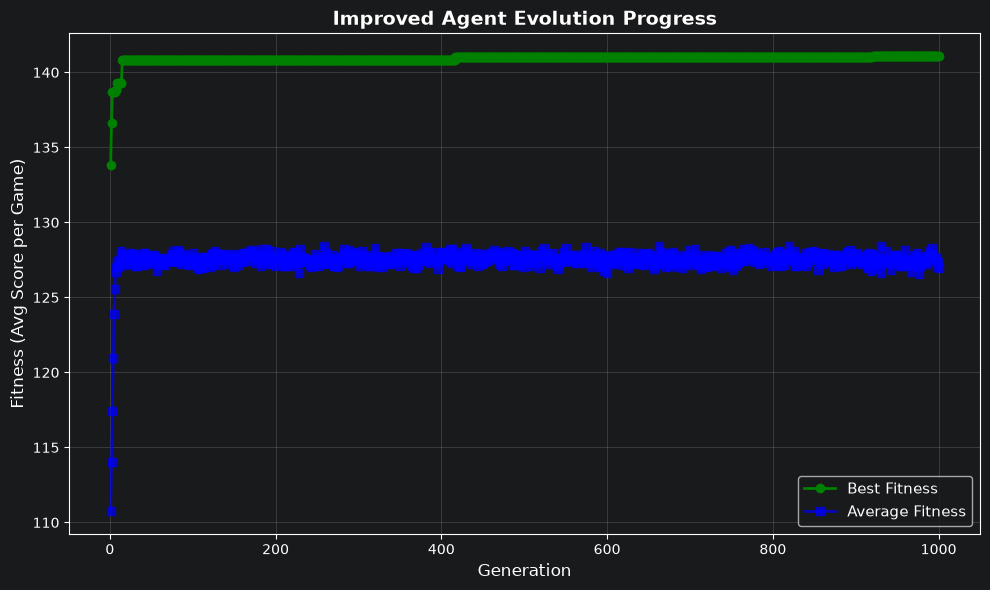


🎉 Your improved agent's final genes:
   [1.0, 0.27069500627420273, 1.0, 0.0, 0.8713142535785792, 0.0]


In [154]:
# ============================================================================
# PART 7: EVOLVE YOUR IMPROVED AGENT
# ============================================================================


print("\n" + "="*70)
print("🔧 EVOLVING YOUR IMPROVED AGENT!")
print("="*70)


def evolve_improved(generations=25, pop_size=20, opponents=None, mutation_rate=0.15, elitism=2):
    """
    Evolve using the ImprovedEvolvableAgent class
    (Same as evolve() but uses ImprovedEvolvableAgent instead of EvolvableAgent)
    """
    if opponents is None:
        opponents = opponent_pool
    
    print(f"\n🧬 EVOLUTION STARTING (Improved Agent)")
    print(f"{'='*70}")
    print(f"Population: {pop_size} | Generations: {generations} | Mutation: {mutation_rate}")
    print(f"Opponents: {len(opponents)} | Elitism: {elitism}")
    print(f"{'='*70}\n")
    
    best_fitness_history = []
    avg_fitness_history = []
    
    # Initialize population with ImprovedEvolvableAgent
    population = [ImprovedEvolvableAgent(name=f"Agent_{i}") for i in range(pop_size)]
    
    best_overall_agent = None
    best_overall_fitness = -float('inf')
    
    for gen in range(generations):
        # Evaluate fitness
        fitnesses = []
        for agent in population:
            fitness = evaluate_fitness(agent, opponents, num_rounds=50)
            fitnesses.append(fitness)
        
        # Track best
        best_fitness = max(fitnesses)
        avg_fitness = sum(fitnesses) / len(fitnesses)
        
        # Update best overall
        best_idx = fitnesses.index(best_fitness)
        if best_fitness > best_overall_fitness:
            best_overall_fitness = best_fitness
            best_overall_agent = ImprovedEvolvableAgent(genes=population[best_idx].genes.copy())
        
        best_fitness_history.append(best_overall_fitness)
        avg_fitness_history.append(avg_fitness)
        
        print(f"Gen {gen+1:3d}/{generations}: "
              f"Best={best_overall_fitness:6.2f} | Avg={avg_fitness:6.2f} | "
              f"Genes={[f'{g:.2f}' for g in population[best_idx].genes]}")
        
        # Create next generation
        if gen < generations - 1:
            sorted_indices = sorted(range(len(fitnesses)), 
                                  key=lambda i: fitnesses[i], 
                                  reverse=True)
            
            # Elitism
            next_population = []
            for i in range(elitism):
                elite_genes = population[sorted_indices[i]].genes.copy()
                next_population.append(ImprovedEvolvableAgent(genes=elite_genes))
            
            # Selection
            selected = tournament_selection(population, fitnesses)
            
            # Crossover and mutation
            while len(next_population) < pop_size:
                parent1, parent2 = random.sample(selected, 2)
                child = crossover_and_mutate(parent1, parent2, mutation_rate)
                # Convert to ImprovedEvolvableAgent
                next_population.append(ImprovedEvolvableAgent(genes=child.genes))
            
            population = next_population
    
    print(f"\n{'='*70}")
    print(f"✅ EVOLUTION COMPLETE!")
    print(f"🏆 Best fitness achieved: {best_overall_fitness:.2f}")
    print(f"{'='*70}\n")
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, generations+1), best_fitness_history, 
             label='Best Fitness', linewidth=2, color='green', marker='o')
    plt.plot(range(1, generations+1), avg_fitness_history, 
             label='Average Fitness', linewidth=2, color='blue', marker='s', alpha=0.7)
    plt.xlabel('Generation', fontsize=12)
    plt.ylabel('Fitness (Avg Score per Game)', fontsize=12)
    plt.title('Improved Agent Evolution Progress', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return best_overall_agent


# TODO: Experiment with these parameters to find the best improved agent!
# my_improved_agent = evolve_improved(
#     generations=1000,      # Try: 20, 30, 50
#     pop_size=30,         # Try: 15, 20, 30
#     opponents=opponent_pool,
#     mutation_rate=0.1,   # Try: 0.1, 0.15, 0.2
#     elitism=2            # Keep top 2 agents each generation
# )

# Test Settings 2
my_improved_agent = evolve_improved(
    generations=1000,       # Try: 50, 100, 250
    pop_size=1000,         # Try: 15, 20, 30
    opponents=opponent_pool,
    mutation_rate=0.5,  # Try: 0.1, 0.15, 0.2
    elitism=10            # Keep top 10 agents each generation
)


print(f"\n🎉 Your improved agent's final genes:")
print(f"   {my_improved_agent.genes}")

In [155]:

# ============================================================================
# PART 8.1: Compare: Original vs Improved
# ============================================================================

print("\n" + "="*70)
print("📊 COMPARISON: Original vs Improved Agent")
print("="*70 + "\n")

print("ORIGINAL AGENT:")
wins_orig = 0
for opponent in opponent_pool:
    game = Game(my_evolved_agent, opponent, num_rounds=100)
    my_score, opp_score = game.play()
    if my_score > opp_score:
        wins_orig += 1
        result = "✅ WON"
    elif my_score < opp_score:
        result = "❌ LOST"
    else:
        result = "🤝 TIED"
    print(f"vs {opponent.name:25s}: {my_score:3d} - {opp_score:3d}  {result}")

print(f"\nOriginal Win Rate: {wins_orig / len(opponent_pool) * 100:.1f}%")

print("\n" + "-"*70 + "\n")

print("IMPROVED AGENT:")
wins_improved = 0
for opponent in opponent_pool:
    game = Game(my_improved_agent, opponent, num_rounds=100)
    my_score, opp_score = game.play()
    if my_score > opp_score:
        wins_improved += 1
        result = "✅ WON"
    elif my_score < opp_score:
        result = "❌ LOST"
    else:
        result = "🤝 TIED"
    print(f"vs {opponent.name:25s}: {my_score:3d} - {opp_score:3d}  {result}")

print(f"\nImproved Win Rate: {wins_improved / len(opponent_pool) * 100:.1f}%")

print("\n" + "="*70)
print(f"📈 IMPROVEMENT: +{wins_improved - wins_orig} wins")
print("="*70)


# ============================================================================
# GENERALIZATION TEST: Full Opponent Pool
# ============================================================================

print("\n" + "="*70)
print("🌍 GENERALIZATION TEST: Against ALL Possible Opponents")
print("="*70 + "\n")

print("Testing improved agent against the FULL opponent library:")
print("(including agents it was NOT trained on)\n")

wins_full = 0
losses_full = 0
ties_full = 0

for opponent in full_opponent_pool:
    game = Game(my_improved_agent, opponent, num_rounds=100)
    my_score, opp_score = game.play()
    
    if my_score > opp_score:
        result = "✅ WON"
        wins_full += 1
    elif my_score < opp_score:
        result = "❌ LOST"
        losses_full += 1
    else:
        result = "🤝 TIED"
        ties_full += 1
    
    # Mark if this was a training opponent
    trained_on = "📚" if any(opponent.name == o.name for o in opponent_pool) else "🆕"
    print(f"{trained_on} vs {opponent.name:25s}: {my_score:3d} - {opp_score:3d}  {result}")

print(f"\n📊 Results against ALL {len(full_opponent_pool)} opponents:")
print(f"   Wins: {wins_full} | Losses: {losses_full} | Ties: {ties_full}")
print(f"   Win Rate: {wins_full / len(full_opponent_pool) * 100:.1f}%")
print(f"\n💡 Legend: 📚 = Trained on this opponent | 🆕 = Never seen before")
print("="*70)


📊 COMPARISON: Original vs Improved Agent

ORIGINAL AGENT:
vs Always Undercut          :  97 - 112  ❌ LOST
vs Adaptive                 : 302 - 297  ✅ WON
vs Prober                   : 299 - 299  🤝 TIED
vs Random (0.7)             : 234 - 284  ❌ LOST
vs Grim Trigger             : 103 - 103  🤝 TIED
vs Tit-for-Tat              : 299 - 299  🤝 TIED
vs Random (0.3)             : 213 - 148  ✅ WON
vs Tit-for-Two-Tats         : 300 - 300  🤝 TIED
vs Generous Tit-for-Tat     : 275 - 270  ✅ WON
vs Suspicious Tit-for-Tat   : 297 - 302  ❌ LOST

Original Win Rate: 30.0%

----------------------------------------------------------------------

IMPROVED AGENT:
vs Always Undercut          :  99 - 104  ❌ LOST
vs Adaptive                 : 300 - 300  🤝 TIED
vs Prober                   : 299 - 299  🤝 TIED
vs Random (0.7)             : 332 - 147  ✅ WON
vs Grim Trigger             : 300 - 300  🤝 TIED
vs Tit-for-Tat              : 300 - 300  🤝 TIED
vs Random (0.3)             :  80 - 445  ❌ LOST
vs Tit-for-Two

In [166]:

# ============================================================================
# PART 8.2: Compete in your final tournament
# ============================================================================

print("\n" + "="*70)
print("🏆 FULL TOURNAMENT COMPARISON")
print("="*70 + "\n")

# Create tournament with original agent
print("Running tournament with ORIGINAL agent...")
original_tournament_agents = full_opponent_pool + [my_evolved_agent]
original_tournament = Tournament(original_tournament_agents, rounds_per_match=100, num_tournaments=1)
original_tournament.run_tournament()

# Create tournament with improved agent
print("\n" + "-"*70)
print("\nRunning tournament with IMPROVED agent...")
improved_tournament_agents = full_opponent_pool + [my_improved_agent]
improved_tournament = Tournament(improved_tournament_agents, rounds_per_match=100, num_tournaments=1)
improved_tournament.run_tournament()

# Compare rankings
print("\n" + "="*70)
print("📊 TOURNAMENT RESULTS COMPARISON")
print("="*70 + "\n")

original_rankings = original_tournament.get_rankings()
improved_rankings = improved_tournament.get_rankings()

# Find where each agent placed
original_rank = None
improved_rank = None
original_score = None
improved_score = None

for rank, (name, score) in enumerate(original_rankings, 1):
    if name == my_evolved_agent.name:
        original_rank = rank
        original_score = score

for rank, (name, score) in enumerate(improved_rankings, 1):
    if name == my_improved_agent.name:
        improved_rank = rank
        improved_score = score

print(f"ORIGINAL AGENT:")
print(f"  Rank: {original_rank} / {len(original_rankings)}")
print(f"  Total Score: {original_score:,}")
print()
print(f"IMPROVED AGENT:")
print(f"  Rank: {improved_rank} / {len(improved_rankings)}")
print(f"  Total Score: {improved_score:,}")
print()
print(f"IMPROVEMENT:")
print(f"  Rank Change: {original_rank - improved_rank} positions {'⬆️' if improved_rank < original_rank else '⬇️' if improved_rank > original_rank else '➡️'}")
print(f"  Score Change: +{improved_score - original_score:,} points ({(improved_score - original_score)/original_score*100:.1f}%)")
print("="*70)

# Show full leaderboard
print("\n🏆 IMPROVED AGENT TOURNAMENT LEADERBOARD:")
print("=" * 50)
for rank, (name, score) in enumerate(improved_rankings, 1):
    emoji = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
    marker = " ⭐ YOUR AGENT" if name == my_improved_agent.name else ""
    print(f"{emoji} {rank:2d}. {name:25s}: {score:,} points{marker}")


🏆 FULL TOURNAMENT COMPARISON

Running tournament with ORIGINAL agent...
Running 1 tournament(s) with 19 agents...
Match 1/342: Always Invest vs Tit-for-Tat
Match 2/342: Always Invest vs Grim Trigger
Match 3/342: Always Invest vs Pavlov
Match 4/342: Always Invest vs Tit-for-Two-Tats
Match 5/342: Always Invest vs Generous Tit-for-Tat
Match 6/342: Always Invest vs Adaptive
Match 7/342: Always Invest vs Always Undercut
Match 8/342: Always Invest vs Suspicious Tit-for-Tat
Match 9/342: Always Invest vs Gradual
Match 10/342: Always Invest vs Prober
Match 11/342: Always Invest vs Hard Majority
Match 12/342: Always Invest vs Soft Majority
Match 13/342: Always Invest vs Random (0.9)
Match 14/342: Always Invest vs Random (0.7)
Match 15/342: Always Invest vs Random (0.5)
Match 16/342: Always Invest vs Random (0.3)
Match 17/342: Always Invest vs Random (0.1)
Match 18/342: Always Invest vs Evolved Agent
Match 19/342: Tit-for-Tat vs Always Invest
Match 20/342: Tit-for-Tat vs Grim Trigger
Match 21/34

In [162]:
# ============================================================================
# PART 9: Export Complete Agent as Python Module
# ============================================================================

import inspect
from datetime import datetime

def export_complete_agent(agent, student_name, generations=100, final_fitness=None):
    """
    Export agent as a complete, standalone Python module.
    This preserves BOTH genes AND decision logic so your strategy maintains
    its competitive edge in the tournament!
    
    Args:
        agent: Your evolved ImprovedEvolvableAgent
        student_name: Your name (will be used in class name, e.g., "JohnSmith")
        generations: Number of generations you evolved for
        final_fitness: Your agent's final fitness score (optional)
    
    Returns:
        filename of the exported Python file
    """
    
    # Clean up student name for valid Python class name (remove spaces, special chars)
    clean_name = ''.join(c for c in student_name if c.isalnum())
    
    # Get the actual decision logic code
    decision_code = inspect.getsource(agent.choose_action)
    
    # The source code already has proper indentation from the class,
    # so we don't need to add extra indentation
    
    # Get training opponent names if available
    try:
        opponent_names = [opp.name for opp in opponent_pool]
        opponent_info = f"Trained against: {', '.join(opponent_names[:5])}{'...' if len(opponent_names) > 5 else ''}"
    except:
        opponent_info = "Training opponents: [info not available]"
    
    # Build the complete Python module
    code = f'''#!/usr/bin/env python
"""
Tournament Agent: {agent.name}
Student: {student_name}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

Evolution Details:
- Generations: {generations}
- Final Fitness: {final_fitness if final_fitness else 'N/A'}
- {opponent_info}

Strategy: {agent.description}
"""

from agents import Agent, INVEST, UNDERCUT
import random


class {clean_name}Agent(Agent):
    """
    {agent.name}
    
    {agent.description}
    
    Evolved Genes: {agent.genes}
    """
    
    def __init__(self):
        # These genes were evolved through {generations} generations
        self.genes = {agent.genes}
        
        # Required for tournament compatibility
        self.student_name = "{student_name}"
        
        super().__init__(
            name="{agent.name}",
            description="{agent.description}"
        )
    
{decision_code}


# Convenience function for tournament loading
def get_agent():
    """Return an instance of this agent for tournament use"""
    return {clean_name}Agent()


if __name__ == "__main__":
    # Test that the agent can be instantiated
    agent = get_agent()
    print(f"   Agent loaded successfully: {{agent.name}}")
    print(f"   Genes: {{agent.genes}}")
    print(f"   Description: {{agent.description}}")
'''
    
    # Save to file
    filename = f"{clean_name.lower()}_tournament_agent.py"
    with open(filename, 'w') as f:
        f.write(code)
    
    print("="*70)
    print("✅ COMPLETE TOURNAMENT AGENT EXPORTED!")
    print("="*70)
    print(f"📄 File: {filename}")
    print(f"🏷️  Class: {clean_name}Agent")
    print(f"🧬 Genes: {agent.genes}")
    print()
    print("📦 What's included:")
    print("   ✓ Your evolved gene values")
    print("   ✓ Your complete decision logic (choose_action method)")
    print("   ✓ All metadata and documentation")
    print()
    print("🎯 Next Steps:")
    print(f"   1. Download '{filename}' from Jupyter")
    print("   2. Submit this .py file for the Unit 6 tournament")
    print("   3. Your strategy will compete exactly as it evolved!")
    print()
    print("🧪 Test your export:")
    print(f"   from {filename[:-3]} import get_agent")
    print("   my_agent = get_agent()")
    print("="*70)
    
    return filename


# ============================================================================
# RUN THIS: Export your improved agent
# ============================================================================

print("\n" + "="*70)
print("💾 EXPORTING YOUR TOURNAMENT AGENT")
print("="*70 + "\n")

# TODO: Customize these fields with your information
STUDENT_NAME = "Pongsupa Supapa"  # <-- CHANGE THIS! (e.g., "JohnSmith" or "Alex_Chen")

# TODO: Give your agent a creative name and description
my_improved_agent.name = "KiasuBOT"  # <-- CHANGE THIS! (e.g., "Vengeful Cooperator", "Strategic Punisher")
my_improved_agent.description = "nice most of the time, but hates consecutive betrays"  # <-- CHANGE THIS! (e.g., "Cooperates with cooperative opponents but retaliates quickly against defectors")

print(f"Agent Name: {my_improved_agent.name}")
print(f"Description: {my_improved_agent.description}")
print(f"Genes: {[f'{g:.2f}' for g in my_improved_agent.genes]}\n")

# Export with all the context
exported_file = export_complete_agent(
    agent=my_improved_agent,
    student_name=STUDENT_NAME,
    generations=1000,  # Update if you used different value
    final_fitness=None  # Optionally add your best fitness score (e.g., 85.2)
)

print(f"\n✨ Your agent is ready for tournament competition!")
print(f"   Unlike JSON exports, this preserves your evolved strategy.\n")



💾 EXPORTING YOUR TOURNAMENT AGENT

Agent Name: KiasuBOT
Description: nice most of the time, but hates consecutive betrays
Genes: ['1.00', '0.27', '1.00', '0.00', '0.87', '0.00']

✅ COMPLETE TOURNAMENT AGENT EXPORTED!
📄 File: pongsupasupapa_tournament_agent.py
🏷️  Class: PongsupaSupapaAgent
🧬 Genes: [1.0, 0.27069500627420273, 1.0, 0.0, 0.8713142535785792, 0.0]

📦 What's included:
   ✓ Your evolved gene values
   ✓ Your complete decision logic (choose_action method)
   ✓ All metadata and documentation

🎯 Next Steps:
   1. Download 'pongsupasupapa_tournament_agent.py' from Jupyter
   2. Submit this .py file for the Unit 6 tournament
   3. Your strategy will compete exactly as it evolved!

🧪 Test your export:
   from pongsupasupapa_tournament_agent import get_agent
   my_agent = get_agent()

✨ Your agent is ready for tournament competition!
   Unlike JSON exports, this preserves your evolved strategy.



## Post-Evolution Reflection Questions

### 1. Generalization Analysis
- Compare your agent's performance on training opponents (📚) vs. unseen opponents (🆕)

  My agent's performance on both trained opponents and unseen opponents is well, it can handle unpredictable and some predictable ones. It often gets placed near the top, even with the struggles and issue against always undercut and suspicious tit-for-tat even when I try to counter it in the code.

- Did your agent generalize well or overfit to the training set?

  It did generalize well with every opponent. From the testing, it either tied or won against the unseen opponents, only the two that it has seen that managed to beat my agent. Always undercut and suspicious tit-for-tat kept beating my agent, not by a lot, usually around 5 points.

    📚 vs Always Undercut          :  99 - 104  ❌ LOST
    📚 vs Suspicious Tit-for-Tat   : 296 - 301  ❌ LOST

- What does this suggest about evolving against a random sample vs. fixed opponents?

  I designed the agent to be in such a way that it can classify and detect certain opponent types at the start. But in order to do that, it has to test like prober and can cause it to lose by a few points to certain against. However, this allowed it to develop well to fixed opponents of certain types. Then after a few rounds from the start, the genetic system kicks in and can manage against a random sample so well. The agent manages to beat all of the random consistently, so the hybrid approach seems to be the way to go.

### 2. Tournament Performance
- What was your agent's final tournament rank? 3rd out of 19.
- What was your agent's total score? 4795.
- Look at agents that ranked above and below you - what strategies do they use?

  The above ones are the Grim-Trigger and Gradual, which both punishes the agent after certain amounts of retaliation and increasing for Gradual. While, below is the classic Tit-for-Tat strategy. Ocassionally, when I train, the agent can actually beat the top two but inconsistently, it comes down to a bit of noise too. But I would like to say the fixed strategy does not account for the behavior of the other agents and come hybrid and classification can go a long way.

### 3. Strategy Analysis
Look at your evolved genes: [1.0, 0.27069500627420273, 1.0, 0.0, 0.8713142535785792, 0.0]

For Reference:
Genes:
[0] initial cooperation \
[1] initial strategy duration \
[2] cooperate with cooperative opponents \
[3] forgiveness \
[4] memory length \
[5] consecutive defection tolerance \

- In plain English, what strategy did your agent evolve?

  Based on the reference below, the agent tends to value cooperation as the initial rate of cooperation is full. Then the duration for how long to initial cooperate is 3 rounds, which after those rounds it also maximizes cooperation with cooperative opponents. However, it does not really like to forgive that much during its memory length of 9 rounds, which can also be seen that it does not like to tolerate consecutive defection at all.

- Does it cooperate with cooperators? Does it punish defectors?

  It likes to cooperate a lot with the cooperators, so far that the genes for cooperation is maximized. While it hates defection as it does not tolerate and is not as likely to forgive and will punish the defectors.

- Why do you think evolution discovered this particular strategy?

  I believe it is that evolution prioritizes benefiting the agent and cooperation leads to the maximization of points over all the rounds and opponents. While, punishing agents that tend to defect leads to ensuring that the opponent does not get too many points and ensure that the agent still receive some.

### 4. Trade-offs
Every strategy has strengths and weaknesses.

- Which types of opponents does your agent beat?

  My agent is really good at beating random agents as it can cut through the noise and ensure that it can get points no matter how unpredictable.

- Which types beat your agent?

  Agents that contain a specific behavior that requires some detection will beat my agent as it needs to figure out the strategy and that sacrifices a few rounds worth of points.

- If you could redesign your agent for Unit 6, what would you change?

  If I could redesign, then I would focus on redesigning the classifier to generalize the type of agent to go to a specific gene that works for it. So the agent can run on multiple genes or multiplier to ensure that it can work for any general type of agent. Or also the option of having multiple agents in the backend that has a good router/classifier and send to a specific agent that works.

### 5. The Environment Matters
- You evolved against a random sample of 10 opponents
- The tournament included all 19 opponents
- Unit 6 will include 30+ student agents with unpredictable strategies
- How might your agent perform in that different environment?

I believe that my agent will beat opponents that are more random than predictable ones, I have no figured out a loophole with my system yet. But if the opponent starts "probing" my agent then that can be an issue at the start. KiasuBOT is not strong at the start because it is hardcoded to figure out the agent but then it can process no issue with the genetic algorithm.